Pixel evitati: 98406 su 284592 totali
Percentuale di ottimizzazione: 34.58%
--- 0.20644402503967285 seconds ---


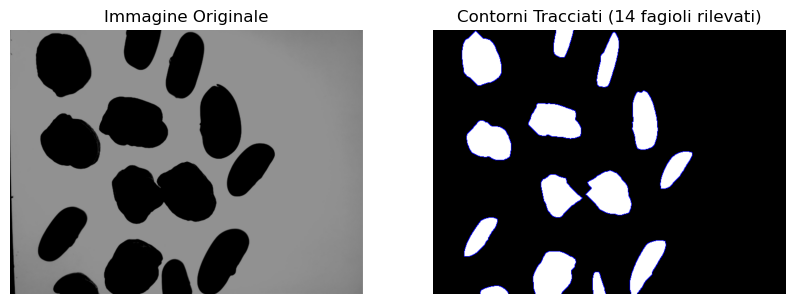

Number of boundaries found: 14


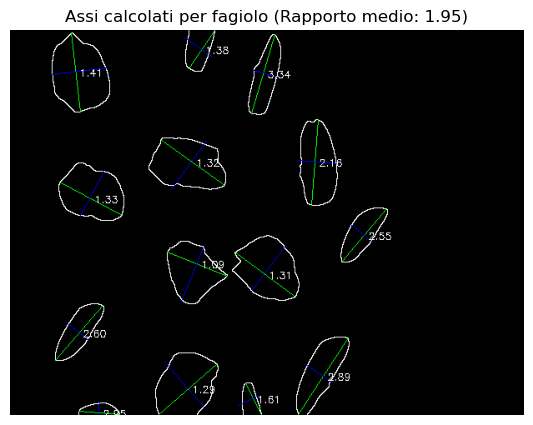

Rapporti individuali per fagiolo:
Fagiolo 1: 1.38
Fagiolo 2: 1.41
Fagiolo 3: 3.34
Fagiolo 4: 2.16
Fagiolo 5: 1.32
Fagiolo 6: 1.33
Fagiolo 7: 2.55
Fagiolo 8: 1.31
Fagiolo 9: 1.09
Fagiolo 10: 2.60
Fagiolo 11: 2.89
Fagiolo 12: 1.29
Fagiolo 13: 1.61
Fagiolo 14: 2.95


In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque

def trace_boundary(binary_image):
    start_time = time.time()
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)
    labels = np.zeros((h, w), dtype=int)
    current_label = 1

    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)

    total_pixels = h * w
    analyzed_pixels = (bottom - top) * (right - left)
    skipped_pixels = total_pixels - analyzed_pixels
    print(f"Pixel evitati: {skipped_pixels} su {total_pixels} totali")
    print(f"Percentuale di ottimizzazione: {skipped_pixels / total_pixels * 100:.2f}%")

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1),
                  (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def bfs(start_i, start_j):
        queue = deque([(start_i, start_j)])
        while queue:
            i, j = queue.popleft()
            if visited[i, j]:
                continue
            visited[i, j] = True
            boundary_mask[i, j] = 255
            labels[i, j] = current_label
            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:
                        for dx2, dy2 in directions:
                            ni2, nj2 = ni + dx2, nj + dy2
                            if 0 <= ni2 < h and 0 <= nj2 < w and binary_image[ni2, nj2] == 0:
                                queue.append((ni, nj))
                                break

    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:
                for dx, dy in directions:
                    ni, nj = i + dx, j + dy
                    if 0 <= ni < h and 0 <= nj < w and binary_image[ni, nj] == 0:
                        bfs(i, j)
                        current_label += 1
                        break

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1

def calculate_axes_and_ratio(boundary_mask, labels, num_labels):
    colored_img = cv2.cvtColor(boundary_mask, cv2.COLOR_GRAY2BGR)
    ratios = []

    for label in range(1, num_labels + 1):
        points = np.argwhere(labels == label)
        if len(points) < 2:
            continue

        pts = points[:, [1, 0]]  # (x, y)

        # Asse maggiore (punti più lontani)
        max_dist = 0
        for i in range(len(pts)):
            for j in range(i+1, len(pts)):
                dist = np.linalg.norm(pts[i] - pts[j])
                if dist > max_dist:
                    max_dist = dist
                    pt1, pt2 = pts[i], pts[j]

        # Punto medio
        midpoint = (pt1 + pt2) // 2
        midpoint = midpoint.astype(int)

        # Vettore unitario dell'asse maggiore
        major_vec = pt2 - pt1
        major_unit = major_vec / np.linalg.norm(major_vec)

        # Vettore perpendicolare (ruotato di 90°)
        perp_unit = np.array([-major_unit[1], major_unit[0]])

        # Proiezione di tutti i punti sull'asse perpendicolare, rispetto al centro
        projections = []
        for p in pts:
            rel_vec = p - midpoint
            proj_len = np.dot(rel_vec, perp_unit)
            proj_point = midpoint + proj_len * perp_unit
            projections.append((proj_len, proj_point))

        min_proj = min(projections, key=lambda x: x[0])[1]
        max_proj = max(projections, key=lambda x: x[0])[1]

        # Lunghezze assi
        major_len = np.linalg.norm(pt2 - pt1)
        minor_len = np.linalg.norm(max_proj - min_proj)
        ratio = major_len / minor_len if minor_len != 0 else 0
        ratios.append(ratio)

        # Disegna assi
        cv2.line(colored_img, tuple(pt1), tuple(pt2), (0,255,0), 1)  # asse maggiore
        cv2.line(colored_img, tuple(min_proj.astype(int)), tuple(max_proj.astype(int)), (0,0,255), 1)  # asse minore
        cv2.putText(colored_img, f"{ratio:.2f}", (midpoint[0]+5, midpoint[1]+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

    return colored_img, ratios

# MAIN
beans_img = cv2.imread('000005.bmp')
if beans_img is None:
    raise FileNotFoundError("Impossibile caricare l'immagine '000005.bmp'. Verifica il percorso.")
img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)

height, width = img_gray.shape
border_x = int(height * 0.02)
border_y = int(width * 0.02)
img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]

threshold = 75
_, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)

kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=15)
kernel_open = np.ones((3,3), np.uint8)
img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)

boundary_mask, labels, num_labels = trace_boundary(img_opened)

colored_boundary = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)
colored_boundary[boundary_mask == 255] = [0, 0, 255]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(beans_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Immagine Originale")

plt.subplot(1,2,2)
plt.imshow(colored_boundary)
plt.axis('off')
plt.title(f"Contorni Tracciati ({num_labels} fagioli rilevati)")
plt.show()

print(f"Number of boundaries found: {num_labels}")

result_img, ratios = calculate_axes_and_ratio(boundary_mask, labels, num_labels)

plt.figure(figsize=(10,5))
plt.imshow(result_img)
plt.axis('off')
plt.title(f"Assi calcolati per fagiolo (Rapporto medio: {np.mean(ratios):.2f})")
plt.show()

print("Rapporti individuali per fagiolo:")
for idx, r in enumerate(ratios, 1):
    print(f"Fagiolo {idx}: {r:.2f}")
